# Avaliação dos modelos preditivos dos pesos FairShap

Este notebook reconstrói os conjuntos usados no cálculo dos pesos FairShap, adiciona o rótulo original às variáveis preditoras e avalia os modelos salvos com a função `avaliar_tradicional_regressor`.

In [1]:
import joblib
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split

import importlib
import func_aux

importlib.reload(func_aux)

from func_aux import avaliar_tradicional_regressor

Arquivo exportado: func_aux.py
Arquivo exportado: func_aux.py


In [2]:
# ============================================================
# Caminhos gerais
# ============================================================

pasta_resultados = Path("resultados")
pasta_splits = pasta_resultados / "splits"
pasta_metricas = pasta_resultados / "metricas"

pasta_metricas.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Parâmetros usados na preparação dos dados
# ============================================================

random_state = 42

# Split usado para separar treino e teste do modelo que
# prediz os pesos FairShap.
test_size_modelo_pesos = 0.30

In [3]:
# ============================================================
# Configurações dos dois modelos
# ============================================================

configuracoes = [
    {
        "dataset": "compas",
        "config_sensivel": "african_american_0",
        "target_col": None,

        "caminho_modelo": Path(
            "resultados/explicabilidade/mitigacoes/fairshap/"
            "compas_african_american_0_arvore_pesos.joblib"
        ),

        "caminho_X_train": (
            pasta_splits
            / "compas_X_train.csv"
        ),

        "caminho_y_train": (
            pasta_splits
            / "compas_y_train.csv"
        ),

        "caminho_pesos": Path(
            "resultados/mitigacoes/fairshap/"
            "compas_pesos_african_american_0.csv"
        )
    },

    {
        "dataset": "hmda",
        "config_sensivel": "african_american_0",

        # Ajuste somente se o nome da variável alvo no arquivo
        # datasets/tratado/hmda.csv for diferente.
        "target_col": "Favorable Outcome (Credit Approved)",

        "caminho_modelo": Path(
            "resultados/explicabilidade/mitigacoes/fairshap/"
            "hmda_african_american_0_arvore_pesos.joblib"
        ),

        "caminho_dataset_tratado": Path(
            "datasets/tratado/hmda.csv"
        ),

        "caminho_pesos": Path(
            "resultados/mitigacoes/fairshap/"
            "hmda_pesos_african_american_0.csv"
        )
    }
]

In [4]:
# ============================================================
# Função para reconstruir o conjunto ao qual os pesos pertencem
# ============================================================

def carregar_dados_fairshap(config):
    nome_dataset = config["dataset"]

    if "hmda" in nome_dataset.lower():

        target_col = config["target_col"]

        df_fairshap = pd.read_csv(
            config["caminho_dataset_tratado"]
        )

        # Mesmo recorte de 50% usado para viabilizar o FairShap
        df_fairshap, _ = train_test_split(
            df_fairshap,
            train_size=0.5,
            random_state=random_state,
            stratify=df_fairshap[target_col]
        )

        df_fairshap = df_fairshap.reset_index(drop=True)

        X_fairshap = df_fairshap.drop(
            columns=[target_col]
        )

        y_fairshap = df_fairshap[
            target_col
        ]

        # Mesmo split usado para formar o conjunto de treinamento
        # sobre o qual os pesos FairShap foram calculados
        (
            X_train_fairshap,
            _,
            y_train_fairshap,
            _
        ) = train_test_split(
            X_fairshap,
            y_fairshap,
            test_size=0.30,
            random_state=random_state,
            stratify=y_fairshap
        )

        X_train_fairshap = (
            X_train_fairshap
            .reset_index(drop=True)
        )

        y_train_fairshap = (
            y_train_fairshap
            .reset_index(drop=True)
        )

    else:

        X_train_fairshap = pd.read_csv(
            config["caminho_X_train"]
        ).reset_index(drop=True)

        y_train_fairshap = pd.read_csv(
            config["caminho_y_train"]
        ).squeeze("columns").reset_index(drop=True)

    pesos_fairshap = pd.read_csv(
        config["caminho_pesos"]
    )["peso_fairshap"].reset_index(drop=True)

    if len(X_train_fairshap) != len(y_train_fairshap):
        raise ValueError(
            f"{nome_dataset}: X e y originais possuem tamanhos diferentes: "
            f"{len(X_train_fairshap)} e {len(y_train_fairshap)}."
        )

    if len(X_train_fairshap) != len(pesos_fairshap):
        raise ValueError(
            f"{nome_dataset}: o conjunto usado pelo FairShap e os pesos "
            f"possuem tamanhos diferentes: "
            f"{len(X_train_fairshap)} e {len(pesos_fairshap)}."
        )

    return (
        X_train_fairshap,
        y_train_fairshap,
        pesos_fairshap
    )

In [5]:
# ============================================================
# Avaliação
# ============================================================

resultados = []


for config in configuracoes:

    nome_dataset = config["dataset"]

    modelo = joblib.load(
        config["caminho_modelo"]
    )

    (
        X_fairshap,
        y_original_fairshap,
        pesos_fairshap
    ) = carregar_dados_fairshap(config)


    # ========================================================
    # Adiciona o label original às variáveis preditoras
    # ========================================================

    X_modelo_pesos = X_fairshap.copy()

    X_modelo_pesos["label"] = (
        y_original_fairshap
        .reset_index(drop=True)
    )


    # ========================================================
    # Split do modelo preditivo dos pesos
    #
    # Deve reproduzir o split usado quando o modelo salvo
    # foi treinado.
    # ========================================================

    (
        _,
        X_test,
        _,
        y_test
    ) = train_test_split(
        X_modelo_pesos,
        pesos_fairshap,
        test_size=test_size_modelo_pesos,
        random_state=random_state
    )

    X_test = X_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)


    # ========================================================
    # Garante a mesma ordem de colunas usada no treinamento
    # ========================================================

    if hasattr(modelo, "feature_names_in_"):
        X_test = X_test[
            modelo.feature_names_in_
        ]


    # ========================================================
    # Conferência antes da avaliação
    # ========================================================

    print(
        f"{nome_dataset}: "
        f"X_test={len(X_test)} | "
        f"y_test={len(y_test)}"
    )


    # ========================================================
    # Métricas tradicionais
    # ========================================================

    metricas = avaliar_tradicional_regressor(
        modelo=modelo,
        X_test=X_test,
        y_test=y_test
    )

    linha = {
        "dataset": nome_dataset,
        "config_sensivel": config["config_sensivel"],
        "modelo": modelo.__class__.__name__
    }

    linha.update(metricas)

    resultados.append(linha)

KeyError: "['alvo'] not in index"

In [ ]:
# ============================================================
# Tabela final
# ============================================================

df_metricas_pesos = pd.DataFrame(
    resultados
)

df_metricas_pesos.to_csv(
    pasta_metricas
    / "metricas_modelos_predicao_pesos.csv",
    index=False
)

display(df_metricas_pesos)

,dataset,config_sensivel,modelo,r2,mae,mse,rmse
0,compas,african_american_0,DecisionTreeRegressor,0.374311,5.141462e-02,8.708049e-03,9.331693e-02
1,hmda,african_american_0,DecisionTreeRegressor,1.000000,8.773490e-12,1.080721e-19,3.287433e-10


# outro - scatter

In [6]:
df_fairshap =pd.read_csv("datasets/tratado/hmda.csv")
target_col ="Favorable Outcome (Credit Approved)"

# Usa 50% do HMDA para reduzir o custo do FairShap
df_fairshap, _ = train_test_split(
    df_fairshap,
    train_size=0.5,
    random_state=42,
    stratify=df_fairshap[target_col]
)

# Importante: reorganiza os índices após a primeira amostragem
df_fairshap = df_fairshap.reset_index(drop=True)

X_train_fairshap = df_fairshap.drop(columns=[target_col])
y_train_fairshap = df_fairshap[target_col]

(
    X_train_fairshap,
    X_test_fairshap,
    y_train_fairshap,
    y_test_fairshap
) = train_test_split(
    X_train_fairshap,
    y_train_fairshap,
    test_size=0.30,
    random_state=42,
    stratify=y_train_fairshap
)



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df_grafico = X_train_fairshap.copy()
df_grafico[target_col] = y_train_fairshap
pesos_fairshap = pd.read_csv(
    "resultados/mitigacoes/fairshap/hmda_pesos_african_american_0.csv"
)["peso_fairshap"].reset_index(drop=True)

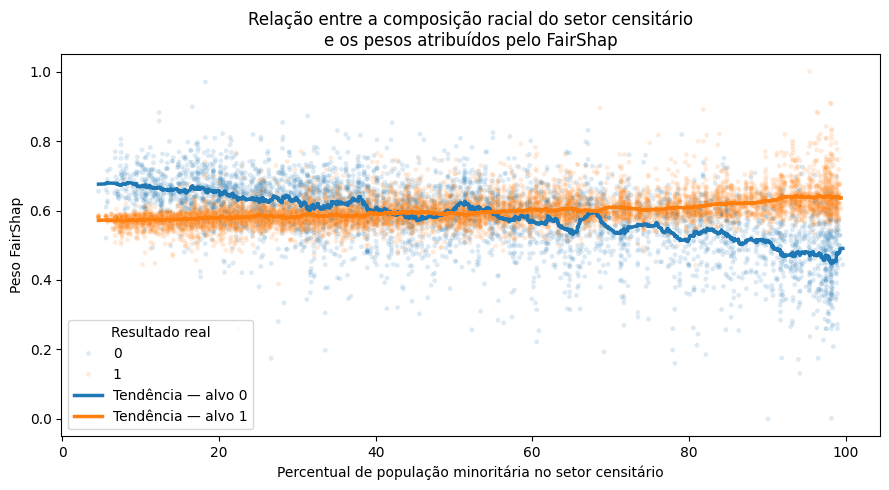

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_grafico = pd.DataFrame({
    "Percentual de população minoritária":
        X_train_fairshap[
            "tract_minority_population_percent"
        ].reset_index(drop=True),

    "Peso FairShap":
        pesos_fairshap.reset_index(drop=True),

    "Alvo":
        y_train_fairshap.reset_index(drop=True)
})


fig, ax = plt.subplots(
    figsize=(9, 5)
)


sns.scatterplot(
    data=df_grafico,
    x="Percentual de população minoritária",
    y="Peso FairShap",
    hue="Alvo",
    alpha=0.15,
    s=12,
    ax=ax
)


for valor_alvo, grupo in df_grafico.groupby("Alvo"):

    grupo = grupo.sort_values(
        "Percentual de população minoritária"
    ).copy()

    grupo["tendencia"] = (
        grupo["Peso FairShap"]
        .rolling(
            window=max(50, len(grupo) // 40),
            center=True,
            min_periods=20
        )
        .mean()
    )

    ax.plot(
        grupo[
            "Percentual de população minoritária"
        ],
        grupo["tendencia"],
        linewidth=2.5,
        label=f"Tendência — alvo {valor_alvo}"
    )


ax.set_title(
    "Relação entre a composição racial do setor censitário\n"
    "e os pesos atribuídos pelo FairShap"
)

ax.set_xlabel(
    "Percentual de população minoritária no setor censitário"
)

ax.set_ylabel(
    "Peso FairShap"
)

ax.legend(
    title="Resultado real"
)

fig.tight_layout()

plt.show()

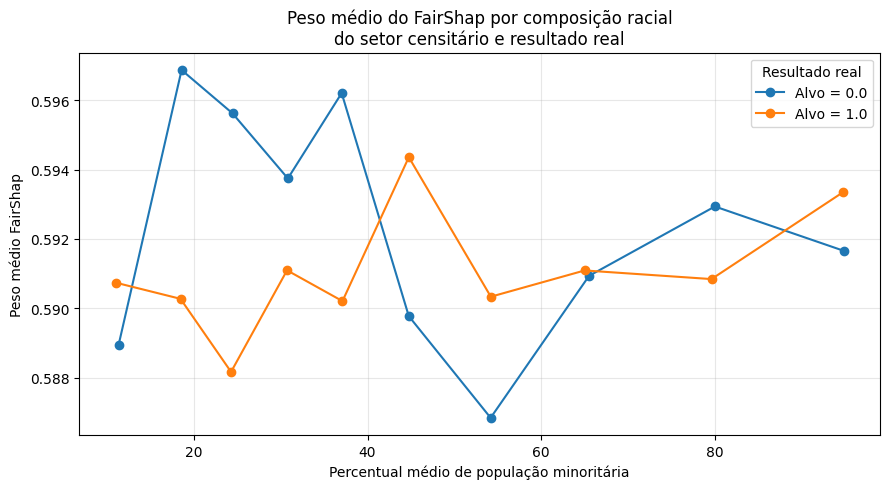

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


df_grafico = pd.DataFrame({
    "percentual_minoritario":
        X_train_fairshap[
            "tract_minority_population_percent"
        ],

    "peso_fairshap":
        pesos_fairshap,

    "alvo":
        y_train_fairshap
})


# Divide a variável contínua em 10 faixas
df_grafico["faixa_percentual"] = pd.qcut(
    df_grafico["percentual_minoritario"],
    q=10,
    duplicates="drop"
)


df_resumo = (
    df_grafico
    .groupby(
        [
            "faixa_percentual",
            "alvo"
        ],
        observed=True
    )
    .agg(
        percentual_medio=(
            "percentual_minoritario",
            "mean"
        ),
        peso_medio=(
            "peso_fairshap",
            "mean"
        )
    )
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)


for valor_alvo, grupo in df_resumo.groupby("alvo"):

    ax.plot(
        grupo["percentual_medio"],
        grupo["peso_medio"],
        marker="o",
        label=f"Alvo = {valor_alvo}"
    )


ax.set_title(
    "Peso médio do FairShap por composição racial\n"
    "do setor censitário e resultado real"
)

ax.set_xlabel(
    "Percentual médio de população minoritária"
)

ax.set_ylabel(
    "Peso médio FairShap"
)

ax.legend(
    title="Resultado real"
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

plt.show()

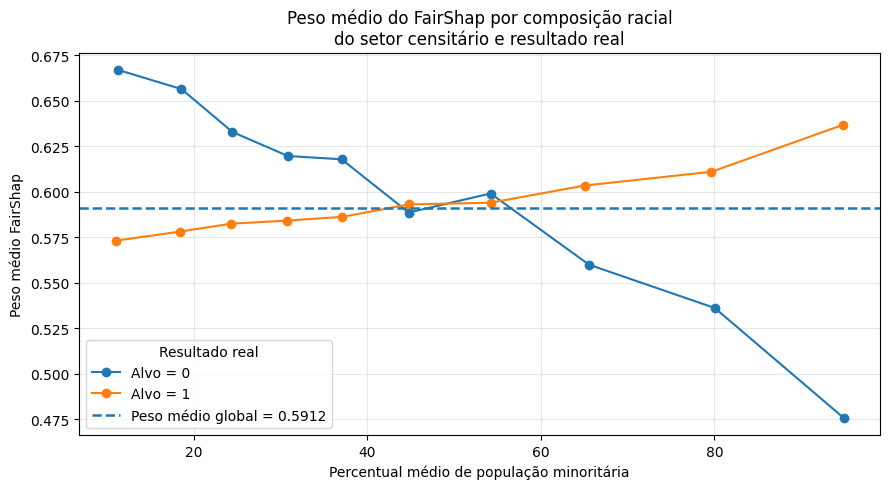

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


df_grafico = pd.DataFrame({
    "percentual_minoritario":
        X_train_fairshap[
            "tract_minority_population_percent"
        ].reset_index(drop=True),

    "peso_fairshap":
        pesos_fairshap.reset_index(drop=True),

    "alvo":
        y_train_fairshap.reset_index(drop=True)
})


peso_medio_global = df_grafico[
    "peso_fairshap"
].mean()


df_grafico["faixa_percentual"] = pd.qcut(
    df_grafico["percentual_minoritario"],
    q=10,
    duplicates="drop"
)


df_resumo = (
    df_grafico
    .groupby(
        [
            "faixa_percentual",
            "alvo"
        ],
        observed=True
    )
    .agg(
        percentual_medio=(
            "percentual_minoritario",
            "mean"
        ),
        peso_medio=(
            "peso_fairshap",
            "mean"
        )
    )
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)


for valor_alvo, grupo in df_resumo.groupby("alvo"):

    ax.plot(
        grupo["percentual_medio"],
        grupo["peso_medio"],
        marker="o",
        label=f"Alvo = {int(valor_alvo)}"
    )


ax.axhline(
    peso_medio_global,
    linestyle="--",
    linewidth=1.8,
    label=(
        f"Peso médio global = "
        f"{peso_medio_global:.4f}"
    )
)


ax.set_title(
    "Peso médio do FairShap por composição racial\n"
    "do setor censitário e resultado real"
)

ax.set_xlabel(
    "Percentual médio de população minoritária"
)

ax.set_ylabel(
    "Peso médio FairShap"
)

ax.legend(
    title="Resultado real"
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

plt.show()

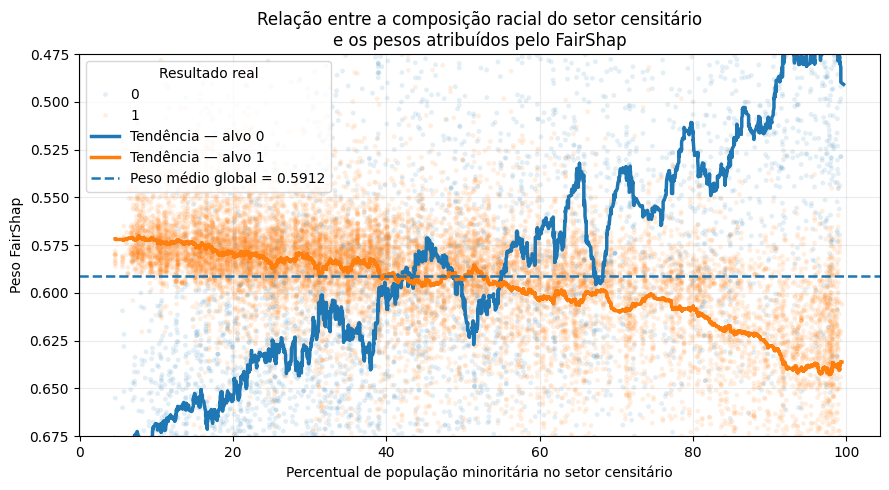

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_grafico = pd.DataFrame({
    "Percentual de população minoritária":
        X_train_fairshap[
            "tract_minority_population_percent"
        ].reset_index(drop=True),

    "Peso FairShap":
        pesos_fairshap.reset_index(drop=True),

    "Alvo":
        y_train_fairshap.reset_index(drop=True)
})


peso_medio_global = df_grafico[
    "Peso FairShap"
].mean()


fig, ax = plt.subplots(
    figsize=(9, 5)
)


sns.scatterplot(
    data=df_grafico,
    x="Percentual de população minoritária",
    y="Peso FairShap",
    hue="Alvo",
    alpha=0.12,
    s=12,
    ax=ax
)


for valor_alvo, grupo in df_grafico.groupby("Alvo"):

    grupo = grupo.sort_values(
        "Percentual de população minoritária"
    ).copy()

    janela = max(
        50,
        len(grupo) // 40
    )

    grupo["tendencia"] = (
        grupo["Peso FairShap"]
        .rolling(
            window=janela,
            center=True,
            min_periods=20
        )
        .mean()
    )

    ax.plot(
        grupo[
            "Percentual de população minoritária"
        ],
        grupo["tendencia"],
        linewidth=2.5,
        label=f"Tendência — alvo {int(valor_alvo)}"
    )


ax.axhline(
    peso_medio_global,
    linestyle="--",
    linewidth=1.8,
    label=(
        f"Peso médio global = "
        f"{peso_medio_global:.4f}"
    )
)


# Mesma faixa aproximada do gráfico por decis
ax.set_ylim(
    0.675,
    0.475
)


ax.set_title(
    "Relação entre a composição racial do setor censitário\n"
    "e os pesos atribuídos pelo FairShap"
)

ax.set_xlabel(
    "Percentual de população minoritária no setor censitário"
)

ax.set_ylabel(
    "Peso FairShap"
)

ax.legend(
    title="Resultado real",
    loc="best"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

plt.show()

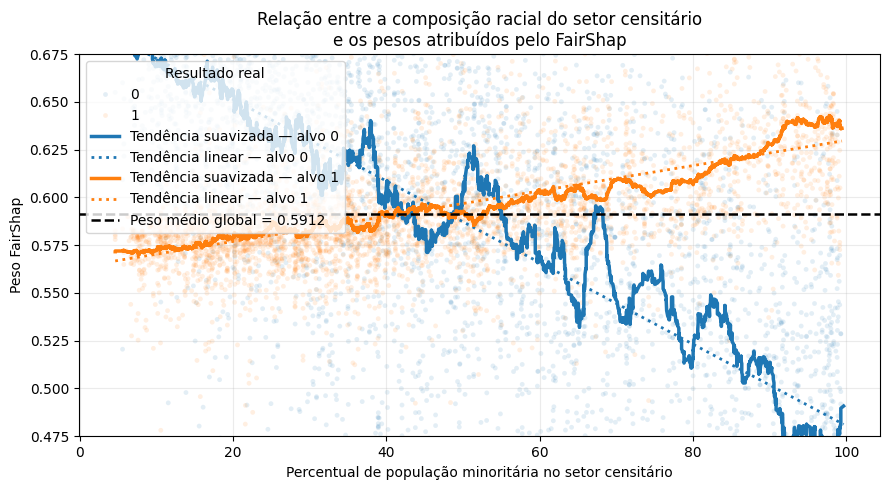

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Opções
# ============================================================

balancear_pontos = True

random_state = 42

limite_inferior_y = 0.475
limite_superior_y = 0.675

limite_inferior_y = 0.675
limite_superior_y = 0.475


# ============================================================
# Dados
# ============================================================

df_grafico = pd.DataFrame({
    "Percentual de população minoritária":
        X_train_fairshap[
            "tract_minority_population_percent"
        ].reset_index(drop=True),

    "Peso FairShap":
        pesos_fairshap.reset_index(drop=True),

    "Alvo":
        y_train_fairshap.reset_index(drop=True)
})


peso_medio_global = df_grafico[
    "Peso FairShap"
].mean()


# ============================================================
# Balanceamento opcional apenas para os pontos
# ============================================================

if balancear_pontos:

    menor_grupo = (
        df_grafico["Alvo"]
        .value_counts()
        .min()
    )

    df_pontos = (
        df_grafico
        .groupby(
            "Alvo",
            group_keys=False
        )
        .sample(
            n=menor_grupo,
            random_state=random_state
        )
        .reset_index(drop=True)
    )

else:

    df_pontos = df_grafico.copy()


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)


# Pontos
sns.scatterplot(
    data=df_pontos,
    x="Percentual de população minoritária",
    y="Peso FairShap",
    hue="Alvo",
    alpha=0.12,
    s=12,
    ax=ax
)


# Recupera as cores usadas automaticamente pelo seaborn
handles, labels = ax.get_legend_handles_labels()

cores_alvos = {
    valor_alvo: handle.get_color()
    for valor_alvo, handle in zip(
        sorted(df_pontos["Alvo"].unique()),
        handles[:df_pontos["Alvo"].nunique()]
    )
}


# ============================================================
# Curva suavizada e reta linear por alvo
# ============================================================

for valor_alvo, grupo in df_grafico.groupby("Alvo"):

    grupo = grupo.sort_values(
        "Percentual de população minoritária"
    ).copy()

    cor = cores_alvos[valor_alvo]

    # Curva suavizada
    janela = max(
        50,
        len(grupo) // 40
    )

    grupo["tendencia_suavizada"] = (
        grupo["Peso FairShap"]
        .rolling(
            window=janela,
            center=True,
            min_periods=20
        )
        .mean()
    )

    ax.plot(
        grupo[
            "Percentual de população minoritária"
        ],
        grupo["tendencia_suavizada"],
        color=cor,
        linewidth=2.5,
        label=f"Tendência suavizada — alvo {int(valor_alvo)}"
    )


    # Reta linear
    x = grupo[
        "Percentual de população minoritária"
    ].to_numpy()

    y = grupo[
        "Peso FairShap"
    ].to_numpy()

    coeficientes = np.polyfit(
        x,
        y,
        deg=1
    )

    x_reta = np.linspace(
        x.min(),
        x.max(),
        200
    )

    y_reta = (
        coeficientes[0] * x_reta
        + coeficientes[1]
    )

    ax.plot(
        x_reta,
        y_reta,
        color=cor,
        linestyle=":",
        linewidth=2,
        label=f"Tendência linear — alvo {int(valor_alvo)}"
    )


# ============================================================
# Média global
# ============================================================

ax.axhline(
    peso_medio_global,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label=(
        f"Peso médio global = "
        f"{peso_medio_global:.4f}"
    )
)


# ============================================================
# Formatação
# ============================================================

ax.set_ylim(
    limite_inferior_y,
    limite_superior_y
)

ax.invert_yaxis()

ax.set_title(
    "Relação entre a composição racial do setor censitário\n"
    "e os pesos atribuídos pelo FairShap"
)

ax.set_xlabel(
    "Percentual de população minoritária no setor censitário"
)

ax.set_ylabel(
    "Peso FairShap"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    title="Resultado real",
    loc="upper left"
)

fig.tight_layout()

plt.show()